## I AVALIAÇÃO PARCIAL
## Complete the Tasks in bold below. Keep in mind, you may need to run some of these tasks as Python scripts.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
CAR_PLATE_BGR_PATH = "car_plate.jpg"
CAR_PLATE_BGR = cv2.imread(CAR_PLATE_BGR_PATH)

COLOR_RED = (255, 0, 0)  # RGB
COLOR_BLUE = (0, 0, 255)  # RGB

----------
#### 1) Open the *car_plate.jpg* image from the DATA folder and display it in the notebook.

In [3]:
CAR_PLATE_BGR_PATH = "car_plate.jpg"

In [4]:
CAR_PLATE_BGR = cv2.imread(CAR_PLATE_BGR_PATH)

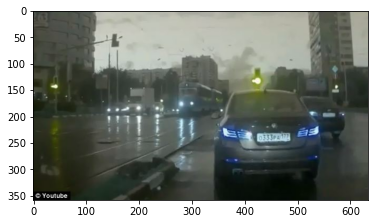

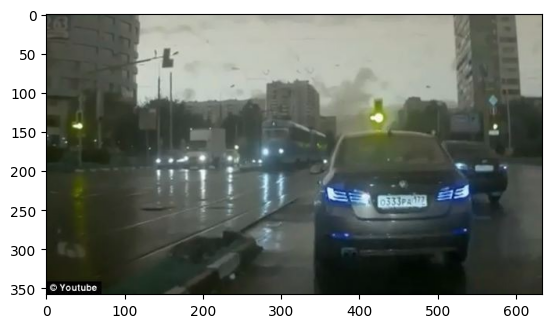

In [5]:
plt.imshow(CAR_PLATE_BGR)

#### 2) Explain what is happenig to the plot. How to fix it up and why do you have to? By answering, show how it actually looks like.

##### A: The image was read in the BGR format. That is why the brake lights looked blue.

In [6]:
CAR_PLATE_RGB = cv2.cvtColor(CAR_PLATE_BGR, cv2.COLOR_BGR2RGB)

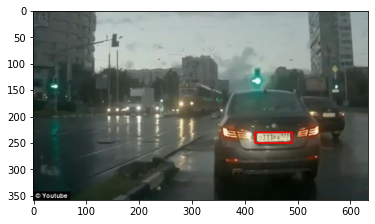

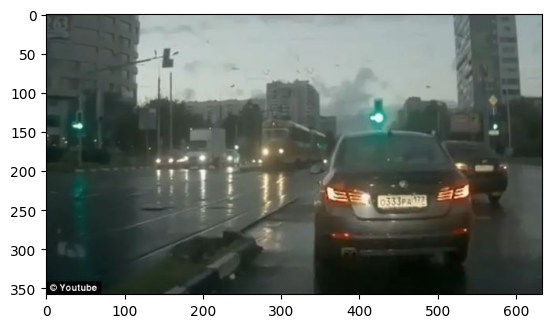

In [7]:
plt.imshow(CAR_PLATE_RGB)

#### 3) Draw an empty RED rectangle around the plate just like the image below.

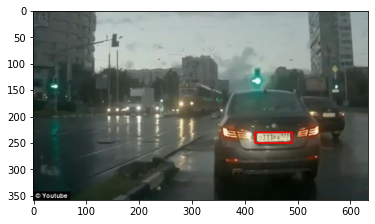

In [8]:
COLOR_RED = (255, 0, 0)  # RGB

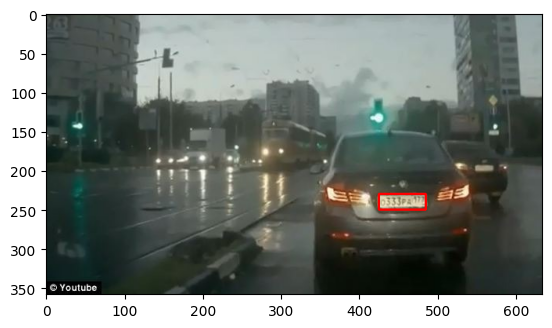

In [9]:
car_plate_rgb = CAR_PLATE_RGB.copy()

cv2.rectangle(car_plate_rgb,
               pt1 = (425, 230), 
               pt2 = (485, 250), 
               color = COLOR_RED,
               thickness = 2)

plt.imshow(car_plate_rgb)

#### 4) Draw a BLUE TRIANGLE in pointing out the car which is changing lane blocking the car which is right behind. See the examplo below.

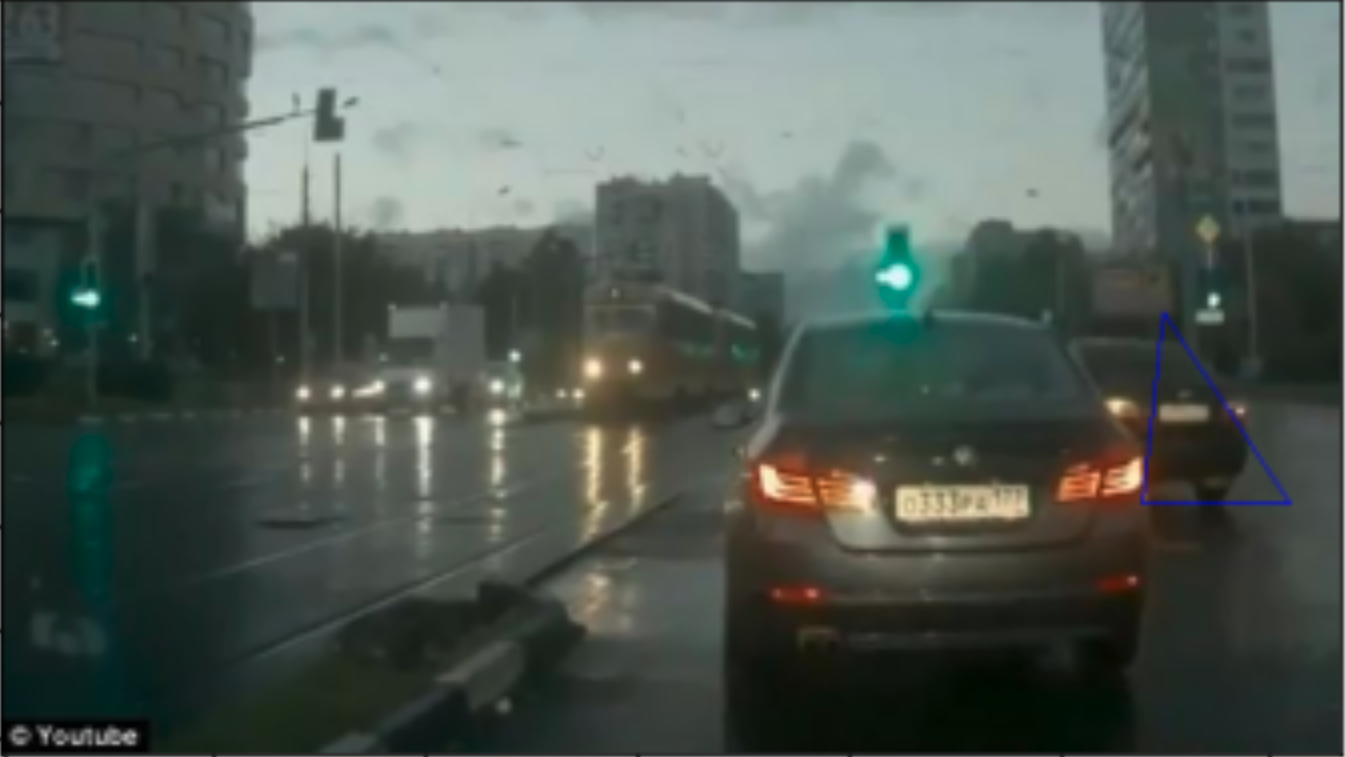

In [10]:
COLOR_BLUE = (0, 0, 255)  # RGB

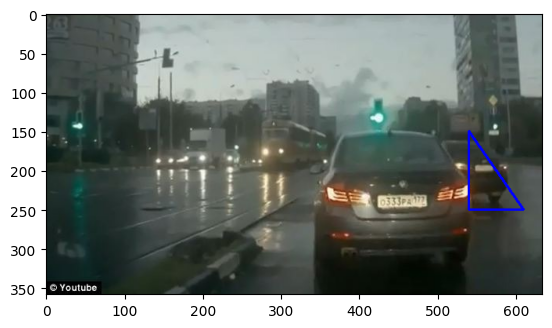

In [11]:
car_blocking_lane = CAR_PLATE_RGB.copy()

coordinates = np.array(((540, 250), 
                        (540, 150), 
                        (610, 250))).reshape((-1, 1, 2))

cv2.polylines(img = car_blocking_lane,
              pts = [coordinates],
              color = COLOR_BLUE,
              isClosed = True,
              thickness = 2)

plt.imshow(car_blocking_lane)

#### 5) (NOTE: YOU WILL NEED TO RUN THIS AS A SCRIPT). Create a script that opens the picture and allows you to draw either filled or empty  red/blue/green circles/rectangle (choose **_one color_\*** and **_one geometric figure_\***). Whenever you click the **_RIGHT_\*** MOUSE BUTTON DOWN.

In [ ]:
# Mouse button:         Right
# One color:            COLOR_RED
# One geometric figure: Circle

def draw_circle(image, event, x, y, flags, param):
    if event == cv2.EVENT_RBUTTONDOWN:
        cv2.circle(image,
                   (x, y),
                   radius = 15,
                   color = COLOR_RED,
                   thickness = -1)

In [ ]:
car_plate_rgb = CAR_PLATE_RGB.copy()

WINDOW_NAME = 'Car Plate'
cv2.namedWindow(WINDOW_NAME)
cv2.setMouseCallback(WINDOW_NAME, draw_circle)

while True:
    cv2.imshow(WINDOW_NAME, car_plate_rgb)
    
    if cv2.waitKey(20) & 0xFF == 27:  # ESC key to break
        break
    
cv2.destroyAllWindows()

#### 6) Explain, step-by-step, all the way through to get two pictures pasted and blended, the meaning for alpha, beta and gamma parameters. Create a ROI and put the small picture into the big one.

##### Answer:

1. Import and convert both images from BGR to RGB;
1. Extract the region of interest from the **biggest\*** image;
1. Extract both gray scale masks (**straight\* and inverse\***) from the smallest image;
1. Mock fore and backgrounds:
    1. **background\***:
        1. with the same dimensions as the smallest image
        1. **inverse\*** gray scale mask
    1. **foreground\***:
        1. same dimensions as the background and the smallest image
        1. **straight\*** gray scale mask
1. **Blend\*** (ROI + Foreground image);
1. FINALLY! **Paste\*** the blend **back\*** on the biggest image.

##### α ⋅ src1 + β ⋅ src2 + γ
- **α\*** and **β\***: Brightness weights for source image 1 and image 2 respectively. These control the balance between both images. The source with the heaviest weight seems to highlight the most. Furthermore, these two weights are often used as complements of 1, for the sake of distributing them as a percentage.
- **γ\***: Brightness weight for the resulting image.